# Introduction

In this project, I will be analyzing the United States GDP Growth Rate from 2010 to 2023. It is sourced from the US Bureau of Economic Analysis, and is recorded quaterly for each fiscal year, but my data set only includes 20 out of the 55 quaters. I will apply 3 separate analytical methods to then draw conclusions from each; Least Squares Linear Regression, Polynomial Fitting, and Cubic Spline Interpolation. I will do this using custom althorigthms rather than using the built-in library functions. After this, I will then justify the choicess I made when fitting the dataset to the chosen models.

# Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_data = np.array([2010.00, 2011.00, 2012.00, 2013.00,
                  2014.00, 2014.50, 2015.25, 2016.00,
                  2016.50, 2016.75, 2017.00, 2018.00,
                  2019.00, 2020.00, 2020.25, 2020.50,
                  2021.00, 2022.00, 2023.25, 2023.75])

x_year = x_data - x_data[0] # This is here to normalize the data. We must normalize the data to prevent float errors with the data when doing polynomial. Without the normalization, I was getting errors due to computing things like 2010⁴, which was causing floating point errors. Found on StackOverflow and Gemini

y_growth = np.array([1.7, .1, 2.3, 2.7, 1.7, 5, 3, 1.5
                     , 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, 
                     -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Part A — Cubic Spline Interpolation

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)
    
    size = n-2
    A = np.zeros(size)  # Subdiagonal
    B = np.zeros(size)  # Main diagonal
    C = np.zeros(size)  # Superdiagonal
    D = np.zeros(size)  # RHS
    
    for i in range(1, n-1):
        idx = i-1
        if idx > 0:
            A[idx] = h[i-1]
        
        B[idx] = 2 * (h[i-1] + h[i])
        
        if idx < size-1:
            C[idx] = h[i]
            
        D[idx] = 6 * ((y[i+1] - y[i])/h[i] - (y[i] - y[i-1])/h[i-1])
        
    return A, B, C, D

def thomas_algorithm(A, B, C, D):
    n = len(D)
    c_star = np.zeros(n)
    d_star = np.zeros(n)
    m = np.zeros(n)
    
    # Forward elimination
    c_star[0] = C[0] / B[0]
    d_star[0] = D[0] / B[0]
    
    for i in range(1, n):
        denom = B[i] - A[i] * c_star[i-1]
        if i < n - 1:
            c_star[i] = C[i] / denom
        d_star[i] = (D[i] - A[i] * d_star[i-1]) / denom
        
    # Backward substitution
    m[-1] = d_star[-1]
    for i in range(n-2, -1, -1):
        m[i] = d_star[i] - c_star[i] * m[i+1]
        
    return m

def evaluate_spline(x_points, y_points, M, x_eval):
    n = len(x_points)
    h = np.diff(x_points)
    y_eval = []
    
    for val in x_eval:
        # Here, it finds which interval val falls into
        if val <= x_points[0]:
            idx = 0
        elif val >= x_points[-2]:
            idx = n - 2
        else:
            idx = np.searchsorted(x_points, val) - 1
            
        hi = h[idx]
        xi = x_points[idx]
        xi1 = x_points[idx+1]
        Mi = M[idx]
        Mi1 = M[idx+1]
        yi = y_points[idx]
        yi1 = y_points[idx+1]
        
        term1 = Mi * (xi1 - val)**3 / (6 * hi)
        term2 = Mi1 * (val - xi)**3 / (6 * hi)
        term3 = (yi - (Mi * hi**2)/6) * (xi1 - val) / hi
        term4 = (yi1 - (Mi1 * hi**2)/6) * (val - xi) / hi
        
        y_eval.append(term1 + term2 + term3 + term4)
        
    return np.array(y_eval)

#Get Matrix Coefficients
A, B, C, D = setup_tridiagonal_matrix(x_year, y_growth)

#Solve for interior second derivatives
M_interior = thomas_algorithm(A, B, C, D)

#Add boundary conditions (Natural Spline: M0 = Mn-1 = 0)
M = np.concatenate(([0], M_interior, [0]))

#For plotting
x_vals = np.linspace(x_year.min(), x_year.max(), 1000) #Increasing to 1000 from 100 to ensure 2020 Q2 is passed through
y_vals = evaluate_spline(x_year, y_growth, M, x_vals)

x_quarters = np.linspace(0, 13.75, 55)

y_quarters_pred = evaluate_spline(x_year, y_growth, M, x_quarters)



x_smooth = np.linspace(0, 13.75, 500)
y_smooth = evaluate_spline(x_year, y_growth, M, x_smooth)

# Create 55 points representing every quarter from 2010 to 2023.75
x_full_range = np.linspace(0, 13.75, 55) 

# Creating data to extrapolate/predict for all 55 points for 2010 Q1 through 2023 Q4
y_full_eval = evaluate_spline(x_year, y_growth, M, x_full_range)

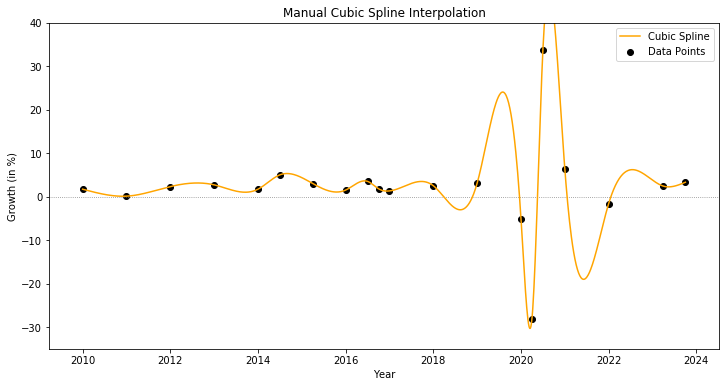

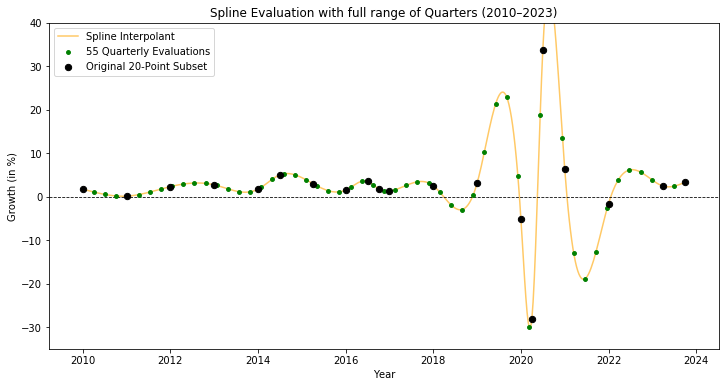

In [3]:
plt.figure(figsize=(12, 6))
plt.xlabel('Year')
plt.ylabel('Growth (in %)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle=':') #Adds an x-axis line to make basline of data more clear
plt.plot(x_vals + x_data[0], y_vals, label='Cubic Spline', color='orange')
plt.scatter(x_year + x_data[0], y_growth, color='black', label='Data Points') #Since I normalized the data earlier, I am simply adding the numbers back in to shift the labels back to the actual years
plt.ylim(-35, 40) #'Zooms in' the data
plt.title("Manual Cubic Spline Interpolation")
plt.legend()
plt.show()

#Interpolation for 55 points
plt.figure(figsize=(12, 6))
plt.xlabel('Year')
plt.ylabel('Growth (in %)')
plt.plot(x_smooth + 2010, y_smooth, label='Spline Interpolant', color='orange', alpha=0.6)
plt.scatter(x_quarters + 2010, y_quarters_pred, color='green', s=15, label='55 Quarterly Evaluations', zorder=3)
plt.scatter(x_data, y_growth, color='black', s=40, edgecolors='black', label='Original 20-Point Subset', zorder=4)
plt.ylim(-35, 40)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Spline Evaluation with full range of Quarters (2010–2023)")
plt.legend()
plt.show()

## Questions

1. To construct the natural cubic spline, the code solves a tridiagonal system using the Thomas Algorithm to find the second derivatives at each data point. For a dataset of n points, there are n-2 unknown interior second derivatives to solve. This system is built upon three specific smoothness conditions enforced at each interior knot where two cubic segments meet. First, the Position Property ensures the spline segments match the data points exactly, meaning S(xi) = yi, which keeps the curve connected. Second, First-Derivative Continuity requires the slopes of the two adjacent segments to be equal at the knot to prevent sharp corners in the trend. Third, Second-Derivative Continuity ensures the curvatures are equal at the knot, providing a smooth transition in the bendiness of the line. Finally, Natural Boundary Conditions are applied by setting the second derivatives at the first and last points to zero. Physically, this implies that the curve carries no acceleration or curvature as it exits the data range, causing the trend to act as a straight line at the boundaries of 2010 Q1 and 2023 Q3

2. After extrapolating the data for all 55 points using the spline, the interpolant is clearly still visually smooth. There are no breaks or tight bends in the line at any point. However, it is not reasonable economically. The crash and rebound in 2020 due to COVID is so extreme that it causes the spline to heavily overshoot the data, leading to a large peak towards Q4 2019 before the crash in 2020. Between 2019 Q1 and 2020 Q2, there is a large gap in the subset data, leading the the spline basically "guessing" where the data trends, and in an effort to remain smooth, it has to create that large overshoot. In the real data, it's much more stable

3. For mant high-degree polynomial fits for many points, the 'Runge Phenomenon' occurs, which presents as the wild, non-uniform 'wiggles" at the edges of an interval. This occurs due to the rigidity of exact interpolation where hitting every point is prioritized over stability. Although it is good to get a smooth curve that honors every piece of data recorded,  you gain the overshooting. Instead, trading off that rigid fitting for numerical stablity is better instead. You can use Smoothing Splines instead where it focuses less on hitting every point and more on closeness to data, or use Weighted Least Squares where outliers like the 2020 data is weighted differently, preventing the line from being pulled and exaggerated.

# Part B — Polynomial & Least Squares Comparison

## Least Squares

In [4]:
outliers = [13, 14, 15, 16] #Defined here and early to removed the COVID values as required

x_edited = np.delete(x_year, outliers)
y_edited = np.delete(y_growth, outliers) #This removes the outliers being the COVID quaters

def custom_least_squares(x_edited, y_edited): #Using a function allows me to be able to input whatever values of x or y I need to later on
    n = len(x_edited)
    
    sum_x  = np.sum(x_edited)
    sum_y  = np.sum(y_edited)
    sum_xsquared = np.sum(x_edited**2)
    sum_xy = np.sum(x_edited * y_edited) #All of these calcuate the method of algorithm steps
    
    m = (n * np.sum(x_edited*y_edited) - np.sum(x_edited)*np.sum(y_edited)) / (n * np.sum(x_edited**2) - (np.sum(x_edited))**2)
    b = (np.sum(y_edited) - m * np.sum(x_edited)) / n #It then solves the two linear equations for m and c.
    return m, b

m_custom, b_custom = custom_least_squares(x_edited, y_edited)

A = np.vstack([x_edited, np.ones(len(x_edited))]).T
m_numpy, b_numpy = np.linalg.lstsq(A, y_edited, rcond=None)[0]

y_custom_pred = m_custom * x_edited + b_custom #Calculates the Y predicted and residuals (actual - predicted)

residuals = y_edited - y_custom_pred

idx_max = np.argmax(np.abs(residuals))#This command is what identifies the points with largest and smallest absolute residual errors
idx_min = np.argmin(np.abs(residuals))

residuals = y_edited - y_custom_pred

print(f"Custom Results: Slope = {m_custom:.4f}, Intercept={b_custom:.4f}")

ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_edited - np.mean(y_edited))**2)
r_squared = 1 - (ss_res / ss_tot)
r_value = np.sqrt(max(0, r_squared))

print(f"R-squared: {r_squared:.4f}")
print(f"Correlation (R): {r_value:.4f}")

mse = np.sqrt(np.mean((y_edited - y_custom_pred)**2))
print(f"RMSE: {mse:.4f}%")

Custom Results: Slope = -0.0076, Intercept=2.1924
R-squared: 0.0004
Correlation (R): 0.0211
RMSE: 1.4432%


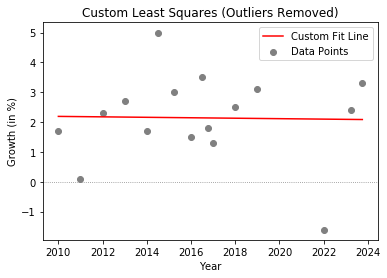

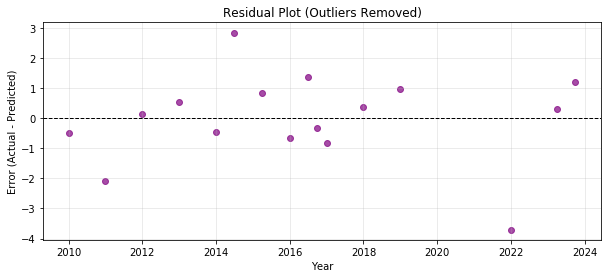

In [5]:
plt.scatter(x_edited + 2010, y_edited, color='gray', label='Data Points')
plt.plot(x_edited + 2010, y_custom_pred, color='red', label='Custom Fit Line')

plt.title('Custom Least Squares (Outliers Removed)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle=':')
plt.xlabel('Year')
plt.ylabel('Growth (in %)')
plt.legend()
plt.show()

residuals_edited = y_edited - y_custom_pred
plt.figure(figsize=(10, 4))
plt.scatter(x_edited + 2010, residuals_edited, color='purple', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Residual Plot (Outliers Removed)')
plt.xlabel('Year')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(alpha=0.3)
plt.show()

In my opinion, no, a linear trend line does not make economic sense. The data set is very scattered and has very little overall trend, which is further backed up by the low R^2 (0.0004), R (0.0211), and RMSE (1.4432%) values. This means the linear model explains only 0.04% of the variation in GDP growthm, showing that the specific year has almost no impact on the GDP growth percentage, and it just simply flucuates. Furthermore, the R of 0.0211 is essentially zero. A perfect relationship is 1 and 0 is no relationship, so it further proves that it is a poor linear fit. Lastly, the RMSE of 1.4432% indicates that, relatively, the line is off by a significant margin. As the GDP growth hovers between 1.5% and 3%, being off by over 1 percentage point is a relatively large error.

## Polynomial

In [6]:
def custom_polyfit(x, y, degree):
    V = np.zeros((len(x), degree + 1))
    for j in range(degree + 1):
        V[:, j] = x**j
    coeffs = np.linalg.solve(V.T @ V, V.T @ y)
    return coeffs

def custom_polyval(coeffs, x_eval):
    y_eval = np.zeros_like(x_eval, dtype=float)
    for j, c in enumerate(coeffs):
        y_eval += c * x_eval**j
    return y_eval

def calculate_metrics(y_actual, y_pred):
    mse = np.mean((y_actual - y_pred)**2)
    r2  = 1 - (np.sum((y_actual - y_pred)**2) /
               np.sum((y_actual - np.mean(y_actual))**2))
    return mse, r2

x_fine = np.linspace(x_year[0], x_year[-1], 1000)
coeffs_poly = custom_polyfit(x_year, y_growth, 4)
y_poly      = custom_polyval(coeffs_poly, x_fine)

y_at_data = custom_polyval(coeffs_poly, x_year)
mse, r2 = calculate_metrics(y_growth, y_at_data)
print(f"Degree 4 | MSE: {mse:.4f} | R²: {r2:.4f}")

y_spline_at_data = evaluate_spline(x_year, y_growth, M, x_year)
mse_s, r2_s = calculate_metrics(y_growth, y_spline_at_data)
print(f"Spline   | MSE: {mse_s:.4f} | R²: {r2_s:.4f}")

Degree 4 | MSE: 100.6298 | R²: 0.0035
Spline   | MSE: 0.0000 | R²: 1.0000


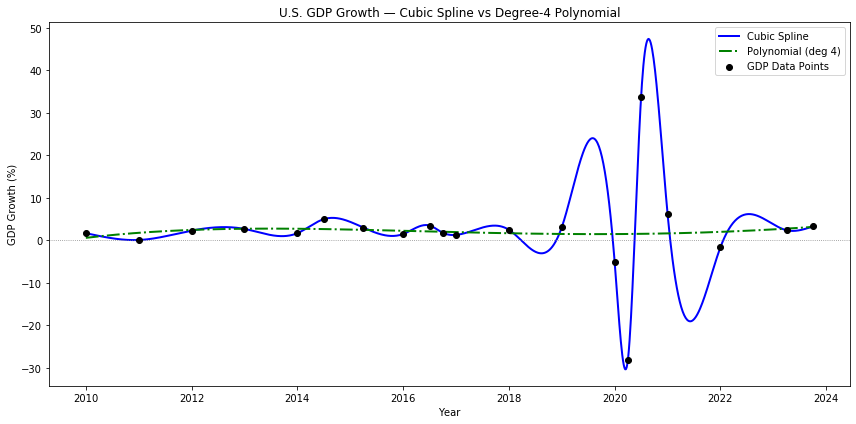

In [7]:
x_fine = np.linspace(x_year[0], x_year[-1], 1000)

plt.figure(figsize=(12, 6))

plt.scatter(x_data,               y_growth, color='black',     zorder=5,   label='GDP Data Points')
plt.plot(x_vals + x_data[0],      y_vals,   color='blue', linewidth=2, label='Cubic Spline')
plt.plot(x_fine + x_data[0],      y_poly,   color='green',  linewidth=2, linestyle='-.', label='Polynomial (deg 4)')

plt.axhline(0, color='gray', linewidth=0.8, linestyle=':')
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')
plt.title('U.S. GDP Growth — Cubic Spline vs Degree-4 Polynomial')
plt.xticks(range(2010, 2025, 2))
plt.legend()
plt.tight_layout()
plt.show()

Overall, In my opinion, the degree-4 polynomial better captures the overall trend, while the cubic spline only better reproduces specific data points. This is clearly justified by the data, as the cubic spline has an MSE of 0.0000 and an R² of 1.0000. These values prove that the spline is better used as an interpolation model as it is mathematically forced to pass through every single coordinate, even extreme outliers like the COVID quaters. Alternatively, the degree-4 polynomial acts more like as an approximation. With an MSE of 100.6298 and an R² of 0.0035, where it fails to hit the specific data it makes up to create a smoother path through the middle of the scattered data. This comparison highlights the fundamental trade-off between interpolation and approximation. As discussed, the cubic spline provides a perfect fit for specific data points, but because it must hit every point, it becomes numerically unstable with the overfits as shown earlier. The degree-4 polynomial avoids these wild swings by not forcing itself to hit the outliers. However, due to the data not necessarily having a correlation, its extremely low R² of 0.0035 shows that it still struggles to find a meaningful pattern. 

Ultimately, the spline is better for reproducing exact historical values, while the polynomial is intended for trend analysis.

## Questions

# Part C — Method Justification

In my opinion, if I were a policymaker, I would recommend using the the cubic spline is technically more accurate despite its issues discussed earlier. This is justified by the stark contrast in the data, where the cubic spline achieves a perfect MSE of 0.0000 and an R² of 1.0000. These values prove that the spline provides better local accuracy by passing exactly through every provided data point, ensuring no information is "lost" at the quarterly level.

The decision for a policymaker comes down to the trade-off between smoothness and sensitivity to outliers. As discussed earlier, The cubic spline offers superior smoothness because it enforces second-derivative continuity, ensuring there are no sharp "jumps" in the growth rate between quarters. However, as seen in the 2020 data, the spline can be highly sensitive to outliers; it forces itself to hit the COVID-19 crash, which causes the entire curve to oscillate and produce unrealistic values in neighboring quarters. However, while an alternative like the polynomial is less sensitive to these outliers, its lack of local accuracy makes it less reliable for estimating a specific value between two points. 

Ultimately, if the data is stable, the spline will the better tool for interpolation due to its mathematical precision. However, it must be used with caution if the surrounding data contains extreme economic anomalies, like as seen with the COVID data.